<a href="https://colab.research.google.com/github/udayjadhav-uj/OIBSIP/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5 

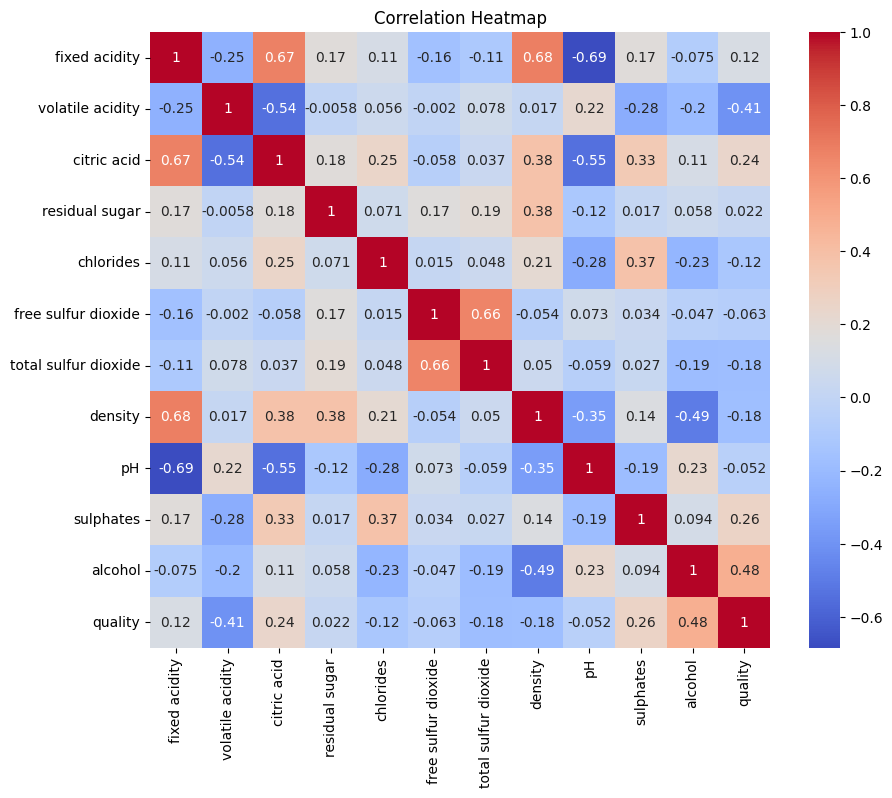


Random Forest Accuracy: 0.7641921397379913
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       102
           1       0.80      0.77      0.78       127

    accuracy                           0.76       229
   macro avg       0.76      0.76      0.76       229
weighted avg       0.77      0.76      0.76       229


SGD Accuracy: 0.7205240174672489
              precision    recall  f1-score   support

           0       0.64      0.86      0.73       102
           1       0.85      0.61      0.71       127

    accuracy                           0.72       229
   macro avg       0.74      0.73      0.72       229
weighted avg       0.75      0.72      0.72       229


SVC Accuracy: 0.7641921397379913
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       102
           1       0.78      0.80      0.79       127

    accuracy                           0.76       229
   macro avg    

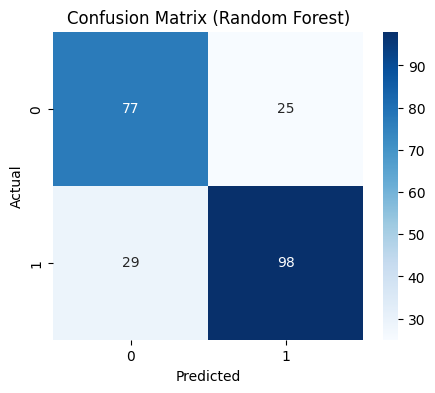

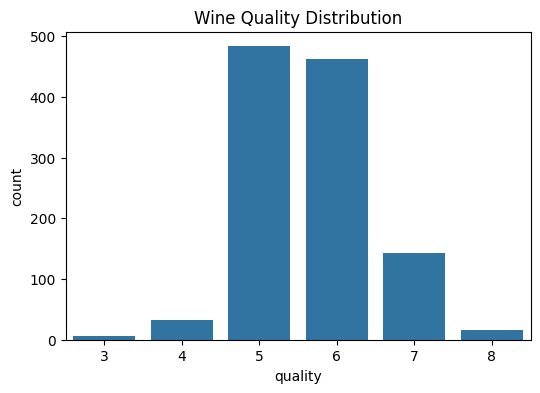

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Load Dataset
df = pd.read_csv("WineQT.csv")

# Display first rows
print("First 5 Rows:")
print(df.head())

# Dataset info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop unnecessary column if present
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Visualization: Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Feature and Target
X = df.drop('quality', axis=1)
y = df['quality']

# Convert quality to classification (Good / Bad)
y = y.apply(lambda x: 1 if x >= 6 else 0)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Random Forest Classifier
# -----------------------------
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# -----------------------------
# Stochastic Gradient Descent
# -----------------------------
sgd = SGDClassifier()
sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

print("\nSGD Accuracy:", accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred))

# -----------------------------
# Support Vector Classifier
# -----------------------------
svc = SVC()
svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

print("\nSVC Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Distribution of Wine Quality
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=df)
plt.title("Wine Quality Distribution")
plt.show()